In [1]:
import os, json, shutil, math
from pathlib import Path

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from tqdm import tqdm
from glob import glob
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

SPLITS_DIR = Path(r"D:\BraTS2020_Splits")
META_PATH  = SPLITS_DIR / "splits_metadata.json"

MOME_BASE = Path(r"D:\MoME_BraTS2020")
MOME_CKPT = MOME_BASE / "checkpoints"
MOME_PRED = MOME_BASE / "predictions_test"
MOME_LOGS = MOME_BASE / "logs"

for p in [MOME_BASE, MOME_CKPT, MOME_PRED, MOME_LOGS]:
    p.mkdir(parents=True, exist_ok=True)

MODS      = ["flair", "t1", "t1ce", "t2"]
N_EXPERTS = len(MODS)   # = 4
N_CLASSES = 4           # 0=bg 1=nec 2=ede 3=enh
DEPTH     = 3
BASE_CH   = 32
PATCH     = 96

FILE_ENDING = ".nii.gz"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NW = 0 if os.name == "nt" else 4

print("Device:", DEVICE)
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name} | VRAM: {props.total_memory/1e9:.1f} GB")

Device: cuda
GPU: NVIDIA GeForce RTX 4070 SUPER | VRAM: 12.9 GB


In [2]:
with open(META_PATH, "r", encoding="utf-8") as f:
    meta = json.load(f)

train_ids = meta["ids"]["train"]
val_ids   = meta["ids"]["val"]
test_ids  = meta["ids"]["test"]

print(f"Train: {len(train_ids)} | Val: {len(val_ids)} | Test: {len(test_ids)}")

Train: 245 | Val: 52 | Test: 53


In [3]:
def case_dir(split_name: str, case_id: str) -> Path:
    return SPLITS_DIR / split_name / case_id

def find_file(folder: Path, key: str) -> Path:
    for cand in [folder / f"{key}.nii.gz", folder / f"{key}.nii"]:
        if cand.exists():
            return cand
    cands = sorted(list(folder.glob(f"*{key}*.nii*")))
    if key == "t1":
        cands = [c for c in cands if "t1ce" not in c.name.lower()]
    if not cands:
        raise FileNotFoundError(f"{key} not found in {folder}")
    return cands[0]

def load_arr(p):
    return np.asanyarray(nib.load(str(p)).dataobj)

def norm01(x, p1=1, p99=99):
    x = x.astype(np.float32)
    lo, hi = np.percentile(x, [p1, p99])
    if hi <= lo:
        return np.zeros_like(x, dtype=np.float32)
    return np.clip((x - lo) / (hi - lo), 0, 1)

def dice_score(a, b):
    inter = np.count_nonzero(a & b)
    denom = np.count_nonzero(a) + np.count_nonzero(b)
    return 1.0 if denom == 0 else (2.0 * inter / denom)

def pick_best_slice(seg, axis=2):
    counts = np.sum(seg > 0, axis=tuple(i for i in range(3) if i != axis))
    return int(np.argmax(counts))

def load_brats_seg(path):
    data = load_arr(path).astype(np.int16)
    data[data == 4] = 3
    return data

In [4]:
class BraTSPatchDataset(Dataset):

    def __init__(self, ids_list, split_name,
                 mode="all", mod_idx=None,
                 patch=PATCH, augment=True):
        assert mode in ("all", "single_expert")
        if mode == "single_expert":
            assert mod_idx is not None, \
                "mod_idx obrigatório para mode='single_expert'"
        self.ids     = ids_list
        self.split   = split_name
        self.mode    = mode
        self.mod_idx = mod_idx
        self.patch   = patch
        self.aug     = augment

    def __len__(self):
        return len(self.ids)

    def _lesion_crop(self, arrays, patch):
        seg    = arrays[-1]
        coords = np.argwhere(seg > 0)
        if len(coords) == 0:
            coords = np.argwhere(np.ones_like(seg))
        center = coords[np.random.randint(len(coords))]
        half   = patch // 2
        lo, hi = [], []
        for ax in range(3):
            c = int(np.clip(center[ax], half, seg.shape[ax] - half))
            lo.append(c - half)
            hi.append(c + half)
        return [a[lo[0]:hi[0], lo[1]:hi[1], lo[2]:hi[2]] for a in arrays]

    def _augment(self, imgs, seg):
        for ax in range(3):
            if np.random.rand() > 0.5:
                imgs = [np.flip(im, axis=ax).copy() for im in imgs]
                seg  = np.flip(seg, axis=ax).copy()
        return imgs, seg

    def __getitem__(self, idx):
        cid = self.ids[idx]
        d   = case_dir(self.split, cid)

        imgs = [norm01(load_arr(find_file(d, m))) for m in MODS]
        seg  = load_brats_seg(find_file(d, "seg"))

        cropped   = self._lesion_crop(imgs + [seg], self.patch)
        imgs, seg = cropped[:-1], cropped[-1]

        if self.aug:
            imgs, seg = self._augment(imgs, seg)

        seg_t = torch.from_numpy(seg.astype(np.int64))  # [P,P,P]

        if self.mode == "all":
            vol = torch.from_numpy(
                np.stack(imgs, axis=0).astype(np.float32))  # [4,P,P,P]
            return vol, seg_t

        # mode="single_expert": retorna APENAS a modalidade fixa — [1,P,P,P]
        # FIX: não usa _to_4ch; tensor 1ch passado diretamente ao expert
        vol = torch.from_numpy(
            imgs[self.mod_idx][None].astype(np.float32))   # [1,P,P,P]
        return vol, seg_t

In [5]:
def double_conv(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv3d(in_ch, out_ch, 3, padding=1, bias=False),
        nn.InstanceNorm3d(out_ch),
        nn.LeakyReLU(0.01, inplace=True),
        nn.Conv3d(out_ch, out_ch, 3, padding=1, bias=False),
        nn.InstanceNorm3d(out_ch),
        nn.LeakyReLU(0.01, inplace=True),
    )


class ExpertUNet(nn.Module):
    def __init__(self, n_cls, base_ch=BASE_CH, depth=DEPTH):
        super().__init__()
        self.depth = depth
        chs = [base_ch * (2 ** i) for i in range(depth + 1)]

        self.enc  = nn.ModuleList()
        self.pool = nn.ModuleList()
        ch_in = 1
        for i in range(depth):
            self.enc.append(double_conv(ch_in, chs[i]))
            self.pool.append(nn.MaxPool3d(2))
            ch_in = chs[i]

        self.bn = double_conv(ch_in, chs[depth])

        self.up   = nn.ModuleList()
        self.dec  = nn.ModuleList()
        self.head = nn.ModuleList()
        for i in range(depth - 1, -1, -1):
            self.up.append(nn.ConvTranspose3d(chs[i+1], chs[i], 2, stride=2))
            self.dec.append(double_conv(chs[i] * 2, chs[i]))
            self.head.append(nn.Conv3d(chs[i], n_cls, 1))

        self.feat_chs = [base_ch * (2 ** i) for i in range(depth)]

    def forward(self, x):
        skips = []
        for enc, pool in zip(self.enc, self.pool):
            x = enc(x)
            skips.append(x)
            x = pool(x)

        x = self.bn(x)

        logits_list, feat_list = [], []
        for i, (up, dec, head) in enumerate(
                zip(self.up, self.dec, self.head)):
            x = up(x)
            x = dec(torch.cat([skips[-(i+1)], x], dim=1))
            feat_list.append(x)
            logits_list.append(head(x))

        return logits_list[::-1], feat_list[::-1]


class GatingNetwork(nn.Module):

    def __init__(self, n_experts, feat_chs_per_level, gate_ch=16):
        super().__init__()
        self.n_experts = n_experts
        self.heads = nn.ModuleList()

        for ch in feat_chs_per_level:
            in_ch = ch * n_experts
            self.heads.append(nn.Sequential(
                nn.Conv3d(in_ch, gate_ch, 3, padding=1, bias=False),
                nn.InstanceNorm3d(gate_ch),
                nn.LeakyReLU(0.01, inplace=True),
                nn.Conv3d(gate_ch, n_experts, 1),
            ))

    def forward(self, feat_lists):
        n_levels  = len(feat_lists[0])
        gate_maps = []
        for lvl in range(n_levels):
            cat   = torch.cat([feat_lists[i][lvl]
                               for i in range(self.n_experts)], dim=1)
            raw   = self.heads[lvl](cat)
            gates = torch.softmax(raw, dim=1)
            gate_maps.append(gates)
        return gate_maps


class MoME(nn.Module):
    def __init__(self, n_experts=N_EXPERTS, n_cls=N_CLASSES,
                 base_ch=BASE_CH, depth=DEPTH):
        super().__init__()
        self.n_experts = n_experts
        self.depth     = depth
        self.n_levels  = depth

        self.experts = nn.ModuleList([
            ExpertUNet(n_cls, base_ch, depth)
            for _ in range(n_experts)
        ])

        feat_chs = self.experts[0].feat_chs
        self.gating = GatingNetwork(n_experts, feat_chs, gate_ch=16)

    def forward(self, x, mode="mome", i_expert=None):
        if mode == "expert":
            assert i_expert is not None
            assert x.shape[1] == 1, \
                "mode='expert' espera tensor [B,1,D,H,W]"
            logits, _ = self.experts[i_expert](x)
            return logits

        all_logits = []
        all_feats  = []

        for i in range(self.n_experts):
            xi = x[:, i:i+1]               # [B, 1, D, H, W]
            logits, feats = self.experts[i](xi)
            all_logits.append(logits)
            all_feats.append(feats)

        gate_maps = self.gating(all_feats)  # [nivel][B, N, D, H, W]

        ensemble_logits = []
        for lvl in range(self.n_levels):
            o = sum(
                all_logits[i][lvl] * gate_maps[lvl][:, i:i+1]
                for i in range(self.n_experts)
            )
            ensemble_logits.append(o)

        return ensemble_logits, all_logits

In [6]:
class DeepSupervisionLoss(nn.Module):

    def __init__(self, n_levels=DEPTH):
        super().__init__()
        raw = [1.0 / (2 ** l) for l in range(n_levels)]
        s   = sum(raw)
        self.weights  = [w / s for w in raw]
        self.n_levels = n_levels

    def soft_dice(self, pred_soft, target_oh):

        smooth = 1e-5
        dims   = (0, 2, 3, 4)
        # Exclui background (canal 0)
        p = pred_soft[:, 1:]
        t = target_oh[:, 1:]
        inter = (p * t).sum(dims)
        denom = p.sum(dims) + t.sum(dims)
        return 1.0 - ((2.0 * inter + smooth) / (denom + smooth)).mean()

    def forward(self, logits_list, target):
        total = 0.0
        for lvl in range(self.n_levels):
            logits = logits_list[lvl]
            w      = self.weights[lvl]

            if lvl == 0:
                tgt = target
            else:
                scale = 1.0 / (2 ** lvl)
                tgt = F.interpolate(
                    target.float().unsqueeze(1),
                    scale_factor=scale, mode="nearest"
                ).squeeze(1).long()

            n_cls = logits.shape[1]
            oh    = F.one_hot(tgt, n_cls).permute(0, 4, 1, 2, 3).float()
            soft  = torch.softmax(logits, dim=1)

            loss_dice = self.soft_dice(soft, oh)
            loss_ce   = F.cross_entropy(logits, tgt)
            total    += w * (loss_dice + loss_ce)

        return total

In [7]:
def curriculum_weight(epoch_cur: int, epoch_total: int) -> float:
    if epoch_total <= 1:
        return 0.0
    return (1.0 - epoch_cur / (epoch_total - 1)) ** 2

In [8]:
def save_expert_ckpt(model: MoME, mod_idx: int, save_dir: Path):
    state = {"expert": model.experts[mod_idx].state_dict()}
    torch.save(state, save_dir / f"expert_{mod_idx}_{MODS[mod_idx]}.pth")

def load_all_expert_ckpts(model: MoME, save_dir: Path):
    for i, mod in enumerate(MODS):
        ckpt_path = save_dir / f"expert_{i}_{mod}.pth"
        if not ckpt_path.exists():
            raise FileNotFoundError(
                f"Checkpoint do expert {i} ({mod}) não encontrado: {ckpt_path}"
            )
        state = torch.load(ckpt_path, map_location=DEVICE)
        model.experts[i].load_state_dict(state["expert"])
        print(f"  ✓ Expert {i} ({mod}) carregado de {ckpt_path.name}")

In [9]:
PRETRAIN_EPOCHS = 30
BATCH_SIZE      = 1
ACCUM_STEPS     = 4
LR_PRETRAIN     = 1e-3
GRAD_CLIP       = 1.0

# FIX: GradScaler apenas quando CUDA disponível
USE_AMP = torch.cuda.is_available()

def pretrain_experts(model: MoME, train_ids, val_ids,
                     epochs=PRETRAIN_EPOCHS, save_dir=MOME_CKPT):
    crit    = DeepSupervisionLoss(n_levels=model.n_levels)
    scaler  = GradScaler("cuda") if USE_AMP else None
    history = {}

    for mod_idx, mod_name in enumerate(MODS):
        print(f"\n{'='*60}")
        print(f" Pré-treino  Expert {mod_idx}  ({mod_name.upper()})")
        print(f"{'='*60}")

        ds_tr = BraTSPatchDataset(
            train_ids, "train",
            mode="single_expert", mod_idx=mod_idx, augment=True)
        ds_va = BraTSPatchDataset(
            val_ids, "val",
            mode="single_expert", mod_idx=mod_idx, augment=False)

        dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NW, pin_memory=USE_AMP)
        dl_va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NW, pin_memory=USE_AMP)

        params = list(model.experts[mod_idx].parameters())
        opt    = torch.optim.AdamW(params, lr=LR_PRETRAIN, weight_decay=1e-5)
        sched  = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=epochs, eta_min=1e-5)

        tr_losses, va_losses = [], []
        best_val = float("inf")

        for epoch in range(epochs):
            model.train()
            running = 0.0
            opt.zero_grad()

            for step, (vol, seg) in enumerate(
                    tqdm(dl_tr,
                         desc=f"Ep {epoch+1:3d}/{epochs} E{mod_idx} train",
                         leave=False)):
                vol = vol.to(DEVICE)
                seg = seg.to(DEVICE)

                # FIX: autocast condicional
                ctx = autocast("cuda") if USE_AMP else torch.no_grad.__class__()
                with autocast("cuda") if USE_AMP else contextlib.nullcontext():
                    # Chama o expert diretamente — MoME.forward mode="expert"
                    logits = model(vol, mode="expert", i_expert=mod_idx)
                    loss   = crit(logits, seg) / ACCUM_STEPS

                if scaler:
                    scaler.scale(loss).backward()
                else:
                    loss.backward()

                if (step + 1) % ACCUM_STEPS == 0:
                    if scaler:
                        scaler.unscale_(opt)
                        torch.nn.utils.clip_grad_norm_(params, GRAD_CLIP)
                        scaler.step(opt)
                        scaler.update()
                    else:
                        torch.nn.utils.clip_grad_norm_(params, GRAD_CLIP)
                        opt.step()
                    opt.zero_grad()

                running += loss.item() * ACCUM_STEPS

            avg_tr = running / max(len(dl_tr), 1)
            tr_losses.append(avg_tr)
            sched.step()

            model.eval()
            running_v = 0.0
            with torch.no_grad():
                for vol, seg in dl_va:
                    vol = vol.to(DEVICE)
                    seg = seg.to(DEVICE)
                    with autocast("cuda") if USE_AMP else contextlib.nullcontext():
                        logits     = model(vol, mode="expert", i_expert=mod_idx)
                        running_v += crit(logits, seg).item()

            avg_va = running_v / max(len(dl_va), 1)
            va_losses.append(avg_va)
            print(f"  Ep {epoch+1:3d} | tr={avg_tr:.4f} | va={avg_va:.4f}")

            if avg_va < best_val:
                best_val = avg_va
                save_expert_ckpt(model, mod_idx, save_dir)
                print(f"    ✓ Expert {mod_idx} salvo (val={best_val:.4f})")

        history[mod_name] = {"train": tr_losses, "val": va_losses}

    with open(MOME_LOGS / "pretrain_history.json", "w") as f:
        json.dump(history, f, indent=2)

    print("\nPré-treino concluído.")
    return history

import contextlib

In [10]:
JOINT_EPOCHS = 60
LR_JOINT     = 1e-3

def train_mome_joint(model: MoME, train_ids, val_ids,
                     epochs=JOINT_EPOCHS, save_dir=MOME_CKPT):

    print(f"\n{'='*60}")
    print(" Treino Conjunto MoME  (curriculum learning)")
    print(f"{'='*60}")

    print("Carregando checkpoints do pré-treino:")
    load_all_expert_ckpts(model, save_dir)

    crit   = DeepSupervisionLoss(n_levels=model.n_levels)
    scaler = GradScaler("cuda") if USE_AMP else None

    ds_tr = BraTSPatchDataset(train_ids, "train", mode="all", augment=True)
    ds_va = BraTSPatchDataset(val_ids,   "val",   mode="all", augment=False)
    dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True,
                       num_workers=NW, pin_memory=USE_AMP)
    dl_va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=NW, pin_memory=USE_AMP)

    opt   = torch.optim.AdamW(model.parameters(),
                               lr=LR_JOINT, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=epochs, eta_min=1e-5)

    tr_losses, va_losses = [], []
    best_val = float("inf")

    for epoch in range(epochs):
        # FIX: curriculum chega exatamente a 0 na última época
        f_ep = curriculum_weight(epoch, epochs)
        model.train()
        running = 0.0
        opt.zero_grad()

        for step, (vol, seg) in enumerate(
                tqdm(dl_tr,
                     desc=f"Ep {epoch+1:3d}/{epochs} joint f={f_ep:.2f}",
                     leave=False)):
            vol = vol.to(DEVICE)
            seg = seg.to(DEVICE)

            with autocast("cuda") if USE_AMP else contextlib.nullcontext():
                ens_logits, ind_logits = model(vol, mode="mome")

                loss_mome = crit(ens_logits, seg)


                loss_spec = sum(
                    crit(ind_logits[i], seg)
                    for i in range(model.n_experts)
                ) / model.n_experts

                # Curriculum (Eq. 2)
                loss = (f_ep * loss_spec + (1.0 - f_ep) * loss_mome) \
                       / ACCUM_STEPS

            if scaler:
                scaler.scale(loss).backward()
            else:
                loss.backward()

            if (step + 1) % ACCUM_STEPS == 0:
                if scaler:
                    scaler.unscale_(opt)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                    scaler.step(opt)
                    scaler.update()
                else:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                    opt.step()
                opt.zero_grad()

            running += loss.item() * ACCUM_STEPS

        avg_tr = running / max(len(dl_tr), 1)
        tr_losses.append(avg_tr)
        sched.step()

        model.eval()
        running_v = 0.0
        with torch.no_grad():
            for vol, seg in dl_va:
                vol = vol.to(DEVICE)
                seg = seg.to(DEVICE)
                with autocast("cuda") if USE_AMP else contextlib.nullcontext():
                    ens_logits, _ = model(vol, mode="mome")
                    running_v    += crit(ens_logits, seg).item()

        avg_va = running_v / max(len(dl_va), 1)
        va_losses.append(avg_va)
        print(f"  Ep {epoch+1:3d} | f={f_ep:.3f} | "
              f"tr={avg_tr:.4f} | va={avg_va:.4f}")

        if avg_va < best_val:
            best_val = avg_va
            torch.save(model.state_dict(), save_dir / "mome_best.pth")
            print(f"    ✓ Melhor checkpoint MoME salvo (val={best_val:.4f})")

    history = {"train": tr_losses, "val": va_losses}
    with open(MOME_LOGS / "joint_history.json", "w") as f:
        json.dump(history, f, indent=2)

    print("\nTreino conjunto concluído.")
    return history

In [11]:
def sliding_window_inference(model: MoME, vol_4ch: np.ndarray,
                              patch=PATCH, overlap=0.5) -> np.ndarray:

    model.eval()
    _, D, H, W = vol_4ch.shape
    step       = max(int(patch * (1.0 - overlap)), 1)

    accum   = np.zeros((N_CLASSES, D, H, W), dtype=np.float32)
    weights = np.zeros((D, H, W), dtype=np.float32)

    def _make_range(dim):
        r = list(range(0, max(dim - patch, 0) + 1, step))
        return r if r else [0]

    with torch.no_grad():
        for z0 in _make_range(D):
            for y0 in _make_range(H):
                for x0 in _make_range(W):
                    z1 = min(z0 + patch, D); z0_ = z1 - patch
                    y1 = min(y0 + patch, H); y0_ = y1 - patch
                    x1 = min(x0 + patch, W); x0_ = x1 - patch

                    patch_np = vol_4ch[:, z0_:z1, y0_:y1, x0_:x1]
                    t = torch.from_numpy(patch_np[None]).to(DEVICE)

                    # FIX: autocast condicional
                    with autocast("cuda") if USE_AMP else contextlib.nullcontext():
                        # FIX: desempacota tupla (ensemble, ind_logits)
                        ens_logits, _ = model(t, mode="mome")
                        prob = torch.softmax(ens_logits[0], dim=1)  # nível fino
                        prob = prob[0].cpu().float().numpy()         # [C,P,P,P]

                    accum[:, z0_:z1, y0_:y1, x0_:x1]   += prob
                    weights[z0_:z1, y0_:y1, x0_:x1]    += 1.0

    accum /= np.maximum(weights[None], 1e-8)
    return accum.argmax(axis=0).astype(np.int16)

In [12]:
def predict_test_set(model: MoME, test_ids,
                     pred_dir=MOME_PRED):
    print(f"\nGerando predições → {pred_dir}")
    model.eval()

    for cid in tqdm(test_ids, desc="Predição test"):
        out_path = pred_dir / f"{cid}.nii.gz"
        if out_path.exists():
            continue

        d    = case_dir("test", cid)
        ref  = nib.load(str(find_file(d, "flair")))
        imgs = [norm01(load_arr(find_file(d, m))) for m in MODS]
        vol  = np.stack(imgs, axis=0).astype(np.float32)  # [4, D, H, W]

        pred = sliding_window_inference(model, vol)
        nib.save(nib.Nifti1Image(pred, ref.affine, ref.header),
                 str(out_path))

    print("Predições concluídas.")

In [13]:
def evaluate_test_set(test_ids, pred_dir=MOME_PRED) -> pd.DataFrame:
    rows = []
    for cid in tqdm(test_ids, desc="Dice por caso"):
        gt_path = find_file(case_dir("test", cid), "seg")
        pr_path = pred_dir / f"{cid}.nii.gz"
        if not pr_path.exists():
            continue

        gt = load_brats_seg(gt_path)
        pr = load_arr(pr_path).astype(np.int16)

        d1 = dice_score(gt == 1, pr == 1)
        d2 = dice_score(gt == 2, pr == 2)
        d3 = dice_score(gt == 3, pr == 3)
        wt = dice_score(gt > 0,  pr > 0)
        tc = dice_score((gt == 1) | (gt == 3), (pr == 1) | (pr == 3))
        et = dice_score(gt == 3, pr == 3)

        rows.append({"id": cid,
                     "dice_c1": d1, "dice_c2": d2, "dice_c3": d3,
                     "dice_WT": wt, "dice_TC": tc, "dice_ET": et})

    df = pd.DataFrame(rows)
    df.to_csv(MOME_LOGS / "dice_test.csv", index=False)
    print("\nResumo Dice (test set):")
    print(df[["dice_WT", "dice_TC", "dice_ET"]].describe().round(4))
    return df

In [14]:
cmap_mask = ListedColormap([
    (0,0,0,1), (1,0,0,1), (0,1,0,1), (0,0,1,1)])
norm_mask = BoundaryNorm([0,1,2,3,4], cmap_mask.N)

def masks_from_seg(seg):
    nec = seg == 1; ede = seg == 2; enh = seg == 3
    wt  = seg > 0;  tc  = (seg==1)|(seg==3); et = seg == 3
    return nec, ede, enh, wt, tc, et

def overlay(ax, base2d, mask2d, color_rgb, alpha=0.45, title=""):
    ax.imshow(base2d, cmap="gray", origin="lower")
    rgba = np.zeros((*mask2d.shape, 4), dtype=np.float32)
    rgba[...,0], rgba[...,1], rgba[...,2] = color_rgb
    rgba[...,3] = mask2d.astype(np.float32) * alpha
    ax.imshow(rgba, origin="lower")
    ax.set_title(title, fontsize=8); ax.axis("off")

def plot_random_case_multimodal_gt_pred(
    ids_list, split_name="test",
    pred_dir=MOME_PRED, seed=None, z=None,
    alpha_cls=0.45, alpha_comp=0.35,
):
    rng = np.random.default_rng(seed)
    cid = str(rng.choice(ids_list))
    d   = case_dir(split_name, cid)

    gt = load_brats_seg(find_file(d, "seg"))
    pr = load_arr(pred_dir / f"{cid}.nii.gz").astype(np.int16)

    if z is None:
        z = pick_best_slice(gt)

    d1  = dice_score(gt==1, pr==1)
    d2  = dice_score(gt==2, pr==2)
    d3  = dice_score(gt==3, pr==3)
    wt  = dice_score(gt>0,  pr>0)
    tc  = dice_score((gt==1)|(gt==3), (pr==1)|(pr==3))
    et  = dice_score(gt==3, pr==3)

    print(f"\nPaciente: {cid} | split={split_name} | z={z}")
    print(f"Dice C1 (necrose):   {d1:.4f}")
    print(f"Dice C2 (edema):     {d2:.4f}")
    print(f"Dice C3 (enhancing): {d3:.4f}")
    print(f"Dice WT:             {wt:.4f}")
    print(f"Dice TC:             {tc:.4f}")
    print(f"Dice ET:             {et:.4f}")

    gt2d = gt[:,:,z].T; pr2d = pr[:,:,z].T
    gt_nec,gt_ede,gt_enh,gt_wt,gt_tc,_ = masks_from_seg(gt2d)
    pr_nec,pr_ede,pr_enh,pr_wt,pr_tc,_ = masks_from_seg(pr2d)

    fig, axes = plt.subplots(2*len(MODS), 7,
                             figsize=(28, 3.2*2*len(MODS)))
    fig.suptitle(f"MoME | {cid} | z={z}", y=1.01)

    for i, mod in enumerate(MODS):
        img2d = norm01(load_arr(find_file(d, mod))[:,:,z]).T
        r_gt, r_pr = 2*i, 2*i+1

        axes[r_gt,0].imshow(img2d,cmap="gray",origin="lower")
        axes[r_gt,0].set_title(f"GT • {mod.upper()}",fontsize=8)
        axes[r_gt,0].axis("off")
        axes[r_gt,1].imshow(gt2d,cmap=cmap_mask,norm=norm_mask,origin="lower")
        axes[r_gt,1].set_title("GT • Mask",fontsize=8); axes[r_gt,1].axis("off")
        overlay(axes[r_gt,2], img2d, gt_ede, (0,1,0), alpha_cls, "GT • Edema")
        overlay(axes[r_gt,3], img2d, gt_nec, (1,0,0), alpha_cls, "GT • Necrose")
        overlay(axes[r_gt,4], img2d, gt_enh, (0,0,1), alpha_cls, "GT • Enhancing")
        overlay(axes[r_gt,5], img2d, gt_wt,  (1,1,0), alpha_comp,"GT • WT")
        overlay(axes[r_gt,6], img2d, gt_tc,  (1,0,1), alpha_comp,"GT • TC")

        axes[r_pr,0].imshow(img2d,cmap="gray",origin="lower")
        axes[r_pr,0].set_title(f"PRED • {mod.upper()}",fontsize=8)
        axes[r_pr,0].axis("off")
        axes[r_pr,1].imshow(pr2d,cmap=cmap_mask,norm=norm_mask,origin="lower")
        axes[r_pr,1].set_title("PRED • Mask",fontsize=8); axes[r_pr,1].axis("off")
        overlay(axes[r_pr,2], img2d, pr_ede, (0,1,0), alpha_cls, "PRED • Edema")
        overlay(axes[r_pr,3], img2d, pr_nec, (1,0,0), alpha_cls, "PRED • Necrose")
        overlay(axes[r_pr,4], img2d, pr_enh, (0,0,1), alpha_cls, "PRED • Enhancing")
        overlay(axes[r_pr,5], img2d, pr_wt,  (1,1,0), alpha_comp,"PRED • WT")
        overlay(axes[r_pr,6], img2d, pr_tc,  (1,0,1), alpha_comp,"PRED • TC")

    plt.tight_layout(); plt.show()
    return cid, z, {"dice_c1":d1,"dice_c2":d2,"dice_c3":d3,
                    "dice_WT":wt,"dice_TC":tc,"dice_ET":et}

In [15]:
def plot_loss_curves(pretrain_history: dict, joint_history: dict):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("MoME – Curvas de Loss", fontsize=14)

    ax = axes[0]
    ax.set_title(f"Pré-treino por Expert ({PRETRAIN_EPOCHS} épocas cada)")
    colors = ["tab:blue","tab:orange","tab:green","tab:red"]
    for (mod, h), c in zip(pretrain_history.items(), colors):
        ax.plot(h["train"], c=c, label=f"{mod} train")
        ax.plot(h["val"],   c=c, ls="--", label=f"{mod} val")
    ax.set_xlabel("Época"); ax.set_ylabel("Loss")
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.set_title(f"Treino Conjunto MoME ({JOINT_EPOCHS} épocas)")
    ax.plot(joint_history["train"], label="train")
    ax.plot(joint_history["val"],   ls="--", label="val")
    ax.set_xlabel("Época"); ax.set_ylabel("Loss")
    ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(MOME_LOGS / "loss_curves.png", dpi=150)
    plt.show()


MoME — 4 experts | 22.8 M parâmetros

 Pré-treino  Expert 0  (FLAIR)


  Ep   1 | tr=1.6953 | va=1.3397
    ✓ Expert 0 salvo (val=1.3397)


  Ep   2 | tr=1.2127 | va=1.1291
    ✓ Expert 0 salvo (val=1.1291)


  Ep   3 | tr=1.0726 | va=1.0427
    ✓ Expert 0 salvo (val=1.0427)


  Ep   4 | tr=1.0049 | va=0.9740
    ✓ Expert 0 salvo (val=0.9740)


...

  Ep  60 | f=0.000 | tr=0.3366 | va=0.4077

Treino conjunto concluído.
Melhor modelo MoME carregado.

Gerando predições → D:\MoME_BraTS2020\predictions_test


Predição test: 100%|██████████| 53/53 [03:06<00:00,  3.52s/it]


Predições concluídas.


Dice por caso: 100%|██████████| 53/53 [00:05<00:00, 10.50it/s]



Resumo Dice (test set):
       dice_WT  dice_TC  dice_ET
count  53.0000  53.0000  53.0000
mean    0.8233   0.7494   0.6529
std     0.1274   0.2064   0.2494
min     0.4096   0.0001   0.0000
25%     0.7497   0.6621   0.5419
50%     0.8791   0.8173   0.7201
75%     0.9153   0.8937   0.8485
max     0.9709   0.9557   0.9476


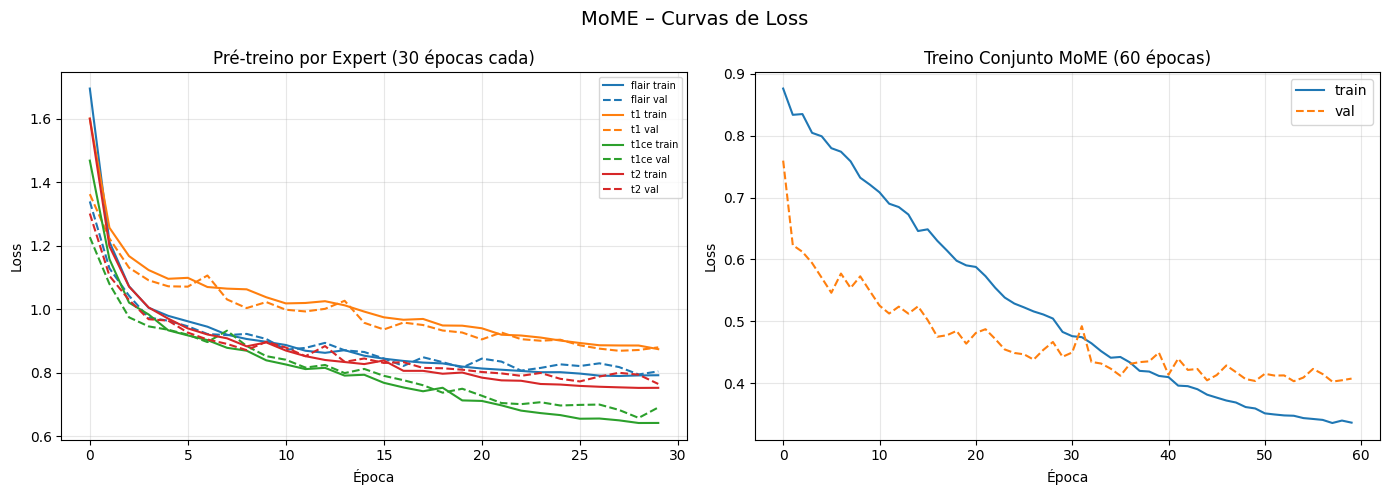


Paciente: BraTS20_Training_062 | split=test | z=92
Dice C1 (necrose):   0.8983
Dice C2 (edema):     0.8771
Dice C3 (enhancing): 0.8567
Dice WT:             0.9245
Dice TC:             0.9303
Dice ET:             0.8567


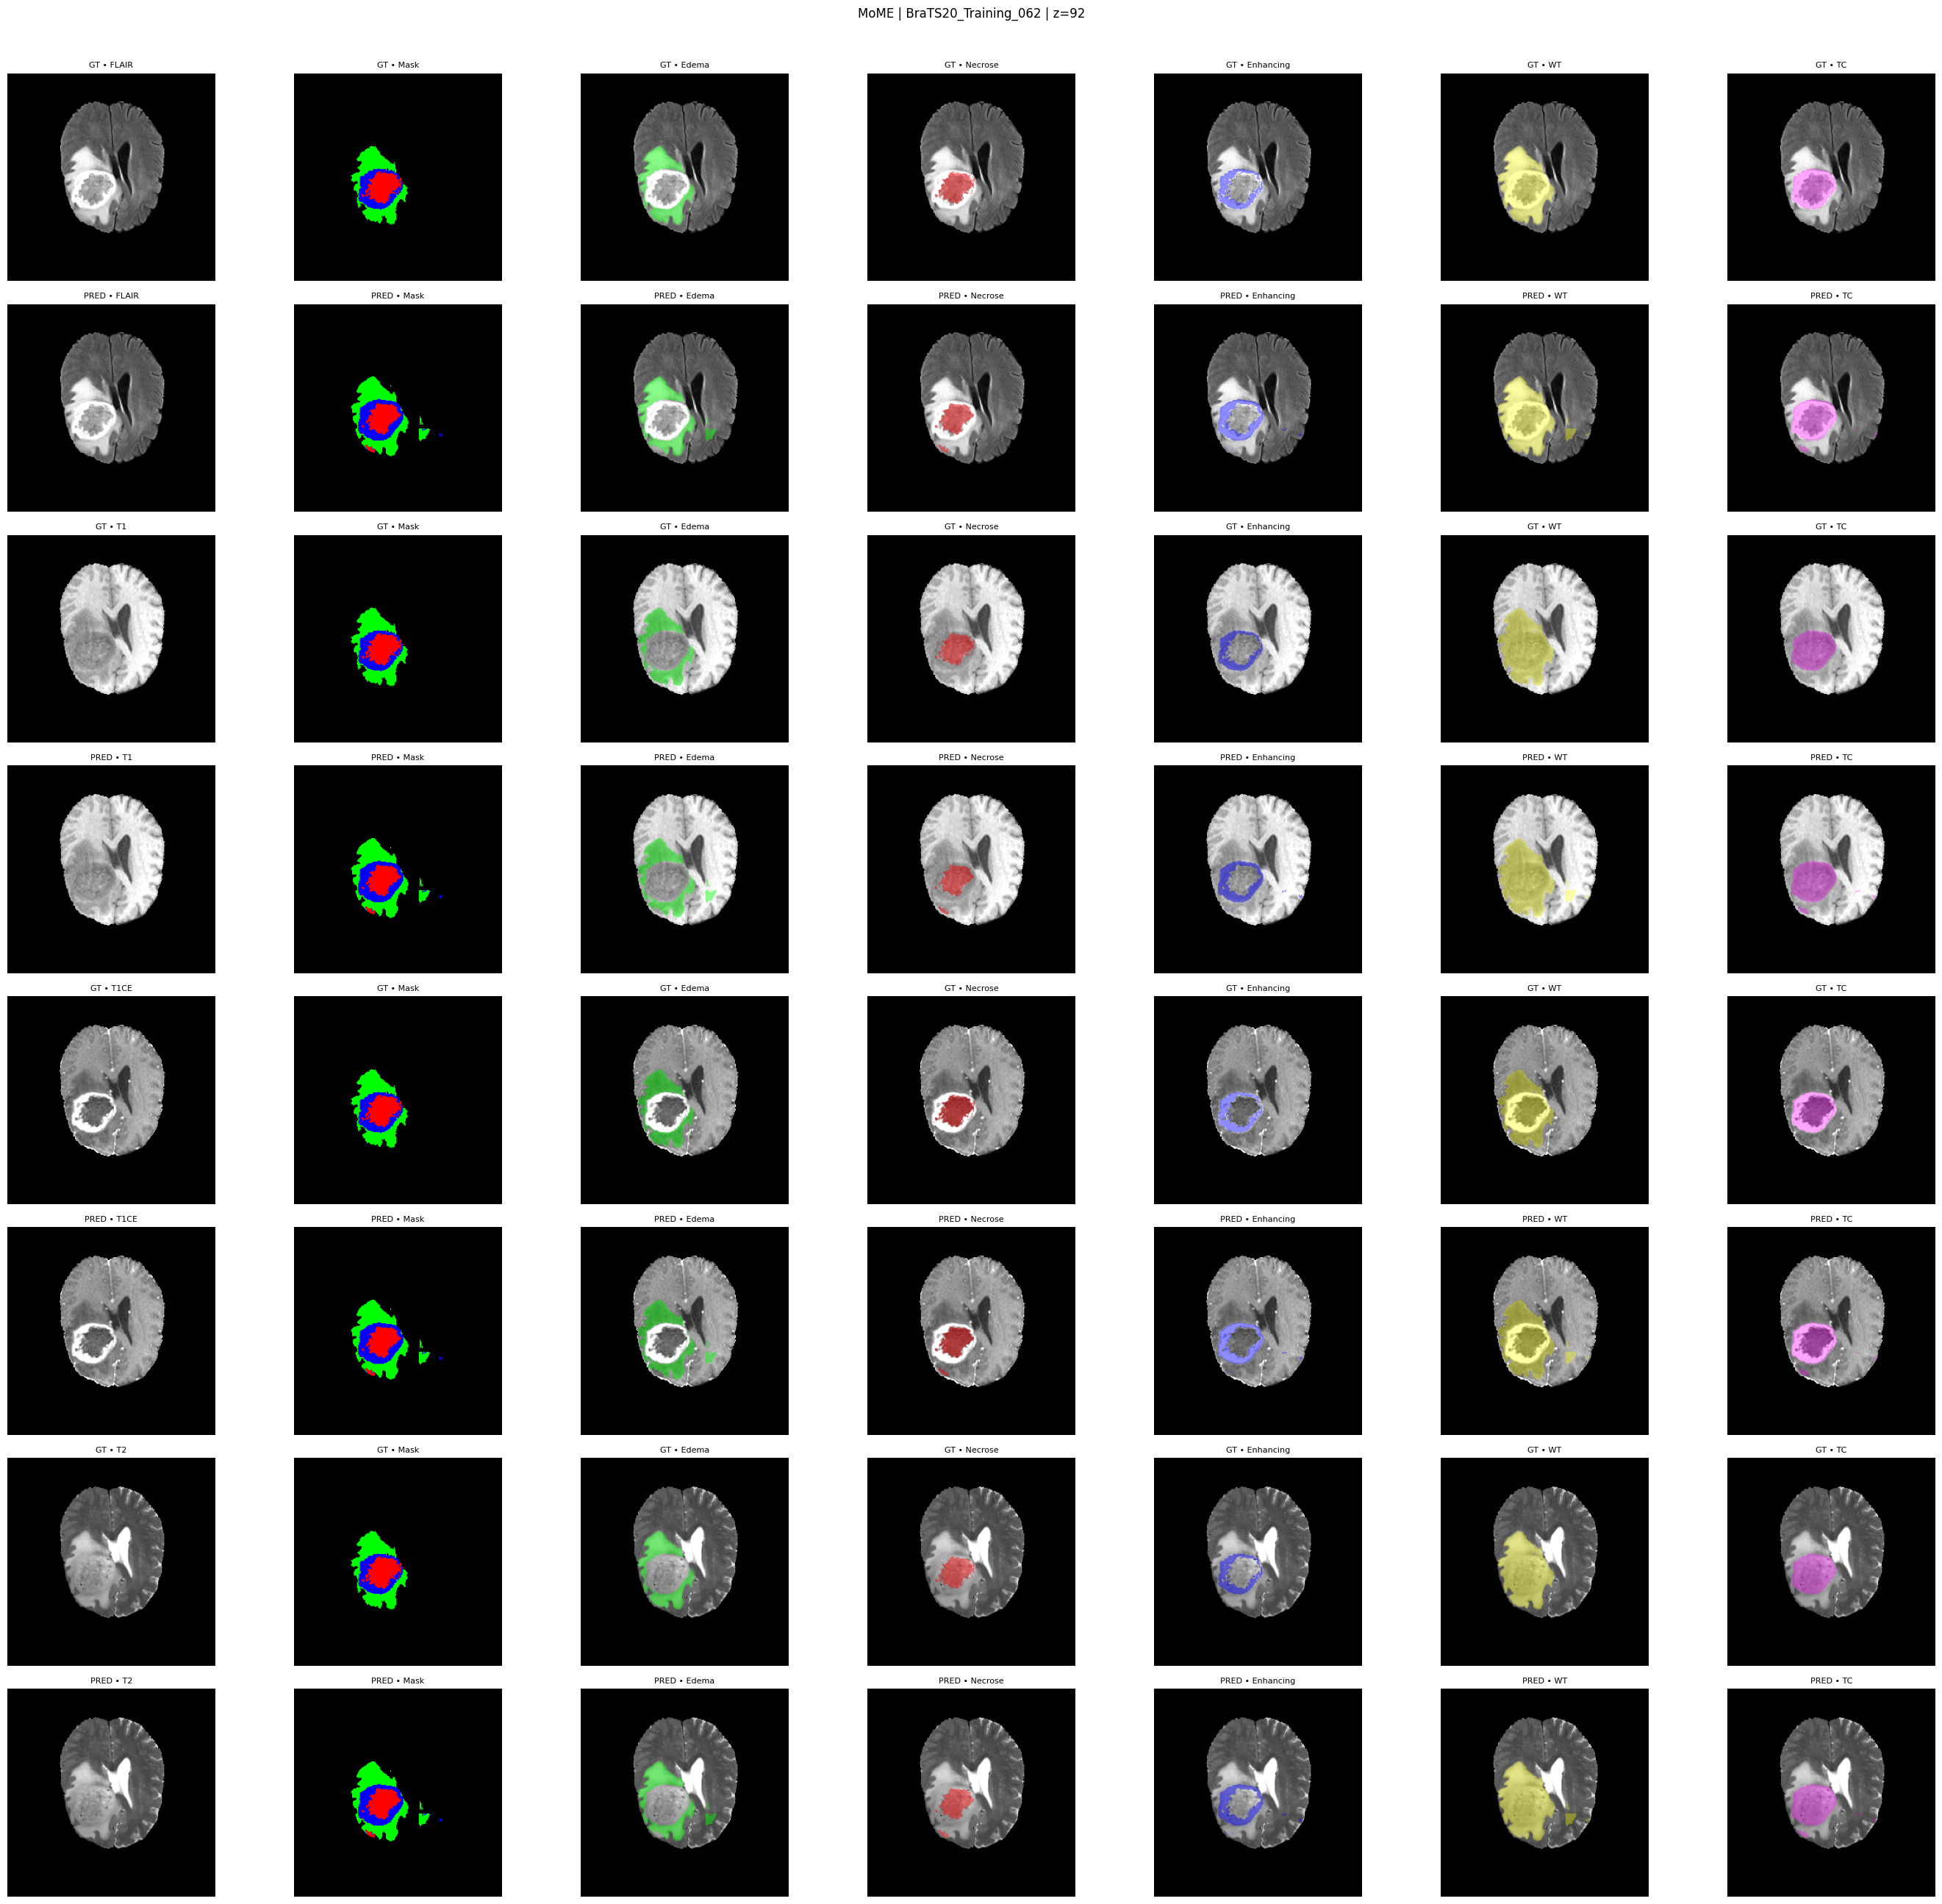

In [16]:
# ── 1. Instancia MoME ────────────────────────────────────────────────────────
model = MoME(
    n_experts=N_EXPERTS,
    n_cls=N_CLASSES,
    base_ch=BASE_CH,
    depth=DEPTH,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"\nMoME — {N_EXPERTS} experts | {n_params:.1f} M parâmetros")

# ── 2. Pré-treino individual ─────────────────────────────────────────────────
pretrain_hist = pretrain_experts(
    model, train_ids, val_ids,
    epochs=PRETRAIN_EPOCHS, save_dir=MOME_CKPT
)

# ── 3. Treino conjunto com curriculum learning ───────────────────────────────
#       load_all_expert_ckpts é chamado internamente
joint_hist = train_mome_joint(
    model, train_ids, val_ids,
    epochs=JOINT_EPOCHS, save_dir=MOME_CKPT
)

# ── 4. Carrega melhor checkpoint ─────────────────────────────────────────────
model.load_state_dict(
    torch.load(MOME_CKPT / "mome_best.pth", map_location=DEVICE))
print("Melhor modelo MoME carregado.")

# ── 5. Predição no conjunto de teste ────────────────────────────────────────
predict_test_set(model, test_ids, pred_dir=MOME_PRED)

# ── 6. Avaliação quantitativa ────────────────────────────────────────────────
df = evaluate_test_set(test_ids, pred_dir=MOME_PRED)

# ── 7. Curvas de loss ────────────────────────────────────────────────────────
plot_loss_curves(pretrain_hist, joint_hist)

# ── 8. Visualização qualitativa ──────────────────────────────────────────────
cid, z, dice_dict = plot_random_case_multimodal_gt_pred(
    test_ids, split_name="test",
    pred_dir=MOME_PRED, seed=None
)